# Factor Analysis — Alpha Signal Evaluation

**Research Question:** Which price-based factors contain predictive information for future returns in a small liquid-equity universe, over what horizon, and with what robustness?

## Factor Hypotheses

| Factor | Type | Formula | Lookback | Signal Direction | Expected Horizon |
|--------|------|---------|----------|-----------------|-----------------|
| Momentum 12-1 | Trend | P(t-21)/P(t-252) − 1 | 252d | Positive = long | Medium (21d+) |
| XS Momentum | Relative | Cross-sectional rank of Momentum | 252d | Higher rank = long | Medium (21d+) |
| RSI | Mean-reversion | 50 − RSI(14) | 14d | Positive = oversold | Short (1-5d) |
| Bollinger | Mean-reversion | −(P − SMA₂₀) / σ₂₀ | 20d | Positive = below band | Short (1-5d) |

## 0. Setup

In [30]:
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from qre.data.historical import HistoricalDataStore
from qre.alpha.factors import BollingerZScore, CrossSectionalMomentum, Momentum, RSI
from qre.analytics.ic import compute_ic, ic_summary, ic_decay
from qre.analytics.metrics import full_summary
from qre.analytics.tearsheet import plot_tearsheet
from qre.backtest.vectorized import VectorizedBacktester

# --- Visual identity ---
sns.set_theme(style="whitegrid")

FACTOR_COLORS = {
    "Momentum 12-1": "#6b1f2b",
    "XS Momentum": "#8b6914",
    "Bollinger": "#2b4b6b",
    "RSI": "#4b6b2b",
}

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

## 1. Data & Universe

In [31]:
store = HistoricalDataStore(adjustment="adjusted")

UNIVERSE = ["AAPL", "AMZN", "GOOGL", "GS", "JNJ", "JPM", "META", "MSFT",
            "NVDA", "PG", "UNH", "V", "WMT", "XOM"]

START = datetime(2020, 1, 1)
END = datetime(2026, 5, 16)

# Backfill all tickers + SPY to 2020
for ticker in UNIVERSE + ["SPY"]:
    _ = store.fetch_and_store(ticker, "1d", START, END)

# Build closes panel (dates x tickers) — SPY kept separate as benchmark
panel = store.load_panel(UNIVERSE + ["SPY"], "1d")
closes = panel["close"]
spy = closes.pop("SPY")

print(f"Universe: {list(closes.columns)}")
print(f"Period: {closes.index.min().date()} to {closes.index.max().date()}")
print(f"Shape: {closes.shape[0]} trading days × {closes.shape[1]} tickers")

Universe: ['AAPL', 'AMZN', 'GOOGL', 'GS', 'JNJ', 'JPM', 'META', 'MSFT', 'NVDA', 'PG', 'UNH', 'V', 'WMT', 'XOM']
Period: 2020-01-02 to 2026-05-15
Shape: 1601 trading days × 14 tickers


In [32]:
# Data quality summary
n_days = closes.shape[0]
missing = closes.isna().sum()

summary_df = pd.DataFrame({
    "Missing Days": missing,
    "Coverage (%)": ((n_days - missing) / n_days * 100).round(1),
})

# Usable days per factor (after lookback burn-off)
lookbacks = {"Momentum 12-1": 252, "XS Momentum": 252, "RSI": 14, "Bollinger": 20}
usable = {name: n_days - lb for name, lb in lookbacks.items()}

print("Usable signal days per factor:")
for name, days in usable.items():
    print(f"  {name}: {days} days (burn-off = {lookbacks[name]}d)")

print(f"\nMissing data per ticker:")
summary_df.style.set_caption("Data Coverage Summary")

Usable signal days per factor:
  Momentum 12-1: 1349 days (burn-off = 252d)
  XS Momentum: 1349 days (burn-off = 252d)
  RSI: 1587 days (burn-off = 14d)
  Bollinger: 1581 days (burn-off = 20d)

Missing data per ticker:


,Missing Days,Coverage (%)
AAPL,0,100.000000
AMZN,0,100.000000
GOOGL,0,100.000000
GS,0,100.000000
JNJ,0,100.000000
JPM,0,100.000000
META,0,100.000000
MSFT,0,100.000000
NVDA,0,100.000000
PG,0,100.000000


**Universe note:** All 14 names are current large-cap equities selected with hindsight. Survivorship bias is present — companies that declined or delisted are excluded. Results likely overstate realised performance. A production system would use a point-in-time universe (e.g., S&P 500 constituents as of each rebalance date).

## 2. Signal Generation

In [33]:
# Instantiate factors
mom = Momentum(window=252, skip=21)
xs_mom = CrossSectionalMomentum(window=252, skip=21)
rsi = RSI(window=14)
boll = BollingerZScore(window=20)

# Compute signals — each returns a DataFrame (dates x tickers)
signals = {
    "Momentum 12-1": mom.compute(closes),
    "XS Momentum": xs_mom.compute(closes),
    "RSI": rsi.compute(closes),
    "Bollinger": boll.compute(closes)
}

# Quick sanity check: first valid index for each factor
for name, sig in signals.items():
    first_valid = sig.dropna(how="all").index[0].date()
    print(f"{name}: first signal on {first_valid} ({sig.notna().sum().sum()} total values)")

Momentum 12-1: first signal on 2020-12-31 (18886 total values)
XS Momentum: first signal on 2020-12-31 (18886 total values)
RSI: first signal on 2020-01-23 (22218 total values)
Bollinger: first signal on 2020-01-30 (22148 total values)


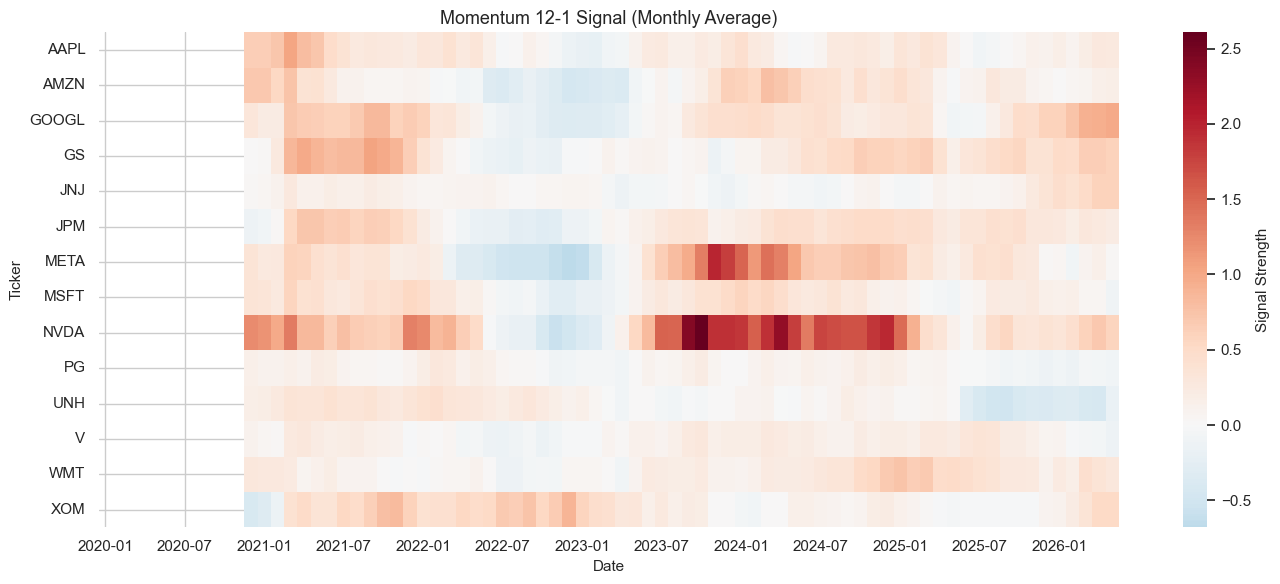

In [34]:
# Monthly-averaged momentum signal for heatmap
mom_monthly = signals["Momentum 12-1"].resample("ME").mean()

# Format index as clean date strings (YYYY-MM)
mom_monthly.index = mom_monthly.index.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    mom_monthly.T,
    cmap="RdBu_r",
    center=0,
    ax=ax,
    xticklabels=6,
    cbar_kws={"label": "Signal Strength"},
)
ax.set_title("Momentum 12-1 Signal (Monthly Average)")
ax.set_xlabel("Date")
ax.set_ylabel("Ticker")
plt.tight_layout()

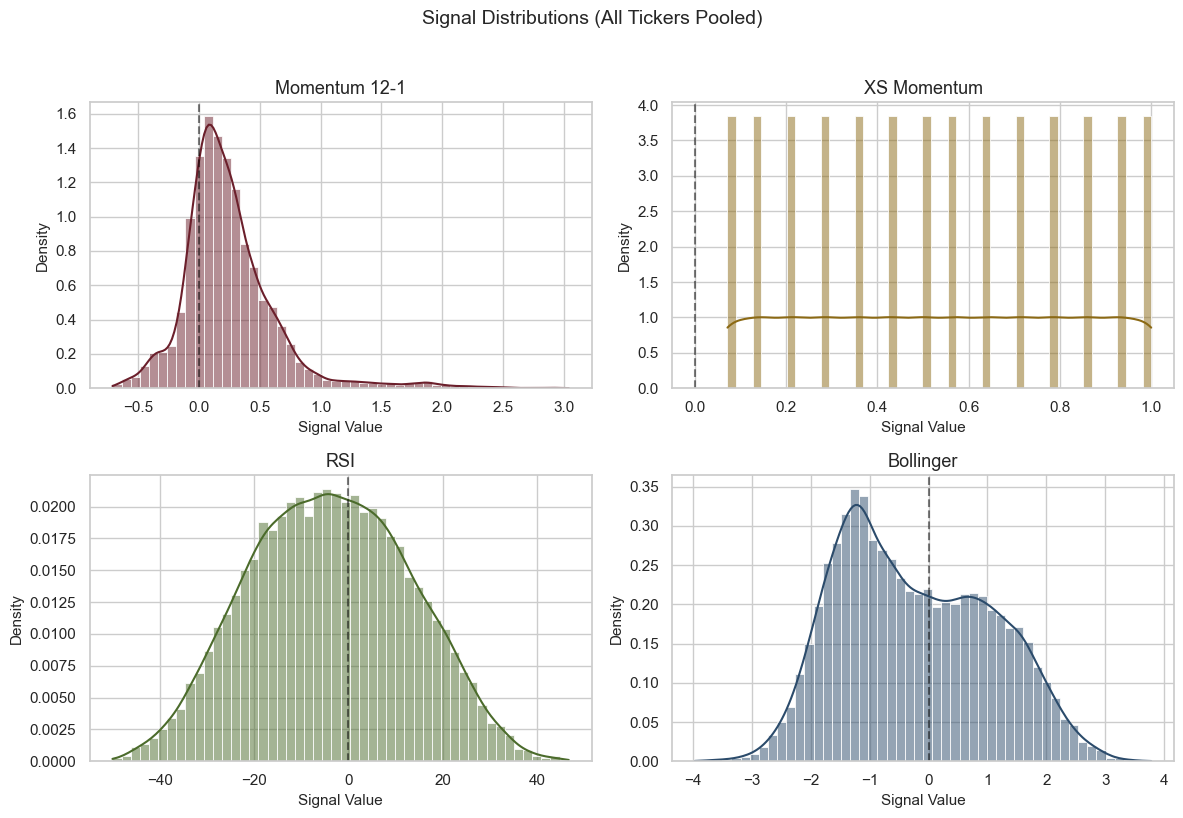

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (name, sig) in zip(axes.flat, signals.items()):
    # Stack all tickers into one Series for the distribution
    values = sig.stack().dropna()

    sns.histplot(
        values,
        bins=50,
        kde=True,
        color=FACTOR_COLORS[name],
        ax=ax,
        stat="density",
    )
    ax.set_title(name)
    ax.set_xlabel("Signal Value")
    ax.axvline(0, color="black", linestyle="--", alpha=0.5)

plt.suptitle("Signal Distributions (All Tickers Pooled)", y=1.02, fontsize=14)
plt.tight_layout()

**Observations:**

- **Momentum 12-1:** Positively biased (mean = 0.25) with strong right skew (1.84) and excess kurtosis (6.6). The right tail extends to +3.0, driven by outlier performers (likely NVDA during 2023-24). The left tail is truncated near -0.71 — a stock can lose at most ~100% but gains are unbounded, making this asymmetry fundamental to momentum signals.
- **XS Momentum:** Approximately uniform over (0, 1] by construction (percentile rank). Skewness is exactly zero; kurtosis is -1.2 (platykurtic), consistent with a discrete uniform distribution across 14 ranks.
- **RSI:** Nearly symmetric (skew ≈ 0) with a slight negative mean (-3.8), indicating stocks in this universe spent marginally more time overbought than oversold over the sample. The distribution is platykurtic (kurtosis = -0.5) — flatter than Gaussian, with values spread broadly across [-50, +47] rather than concentrated at the center.
- **Bollinger:** Negative bias (mean = -0.24, median = -0.40) reflecting the upward drift of equities — prices spend more time above the rolling mean, producing negative signal values after negation. The distribution is platykurtic (kurtosis = -0.8) and notably non-Gaussian: the mode sits left of zero with a steep left dropoff, then flattens into a near-uniform plateau through zero before tapering slowly on the right. This shape arises because the 20-day rolling window conflates trending and mean-reverting regimes, each contributing a different local distribution.

## 3. Forward Returns

We compute forward returns at multiple horizons to test each factor at its expected time scale. Momentum factors are hypothesised to predict at 21d+; mean-reversion factors at 1-5d.

In [36]:
HORIZONS = [1, 5, 10, 21]

forward_returns = {}
for h in HORIZONS:
    # pct_change(h) = cumulative h-day return; shift(-h) aligns it to signal date
    forward_returns[h] = closes.pct_change(h).shift(-h)

print("Forward return shapes:")
for h, fr in forward_returns.items():
    valid = fr.dropna(how="all").shape[0]
    print(f"  {h}d: {valid} usable days")

Forward return shapes:
  1d: 1600 usable days
  5d: 1596 usable days
  10d: 1591 usable days
  21d: 1580 usable days


In [37]:
# Summary statistics for forward returns (pooled across tickers)
stats_rows = []
for h in HORIZONS:
    vals = forward_returns[h].stack().dropna()
    stats_rows.append({
        "Horizon": f"{h}d",
        "Mean (bps)": round(vals.mean() * 10_000, 1),
        "Std (bps)": round(vals.std() * 10_000, 1),
        "Skewness": round(vals.skew(), 2),
        "Kurtosis": round(vals.kurtosis(), 2),
        "N obs": len(vals),
    })

fwd_stats = pd.DataFrame(stats_rows).set_index("Horizon")
fwd_stats.style.set_caption("Forward Return Statistics (All Tickers Pooled)")

,Mean (bps),Std (bps),Skewness,Kurtosis,N obs
Horizon,,,,,
1d,9.600000,206.900000,0.080000,12.130000,22400
5d,47.100000,440.000000,-0.070000,4.210000,22344
10d,93.200000,615.200000,-0.050000,3.010000,22274
21d,195.400000,895.700000,0.150000,2.920000,22120


**Observations:**

- **Mean scales linearly with horizon** (≈10 bps/day): 1d = 9.6 bps, 5d = 47 bps, 10d = 93 bps, 21d = 195 bps. This reflects the average upward drift of the universe (~24% annualised — consistent with a survivorship-biased large-cap sample over 2020-2026).
- **Volatility scales as √h:** 1d std = 207 bps; 21d std = 896 bps. The ratio 896/207 = 4.3 ≈ √21 = 4.6, confirming approximate diffusive scaling and no strong serial correlation in the return series.
- **Kurtosis decays with horizon:** 1d kurtosis = 12.1 (very fat tails — single-day crashes/spikes), declining to ~3.0 at 21d. This is the aggregational Gaussianity effect — longer-horizon returns approach normality by CLT.
- **Skewness is near zero at all horizons**, slightly negative at 5-10d (drawdowns cluster at the weekly/biweekly scale) and slightly positive at 21d (recovery rallies over monthly windows).

*Note: Forward returns use simple percentage changes. For h ≤ 21 days, the difference from log returns is negligible (<5 bps of bias at 21d).*

## 4. IC Analysis

The Information Coefficient (IC) is the daily cross-sectional Spearman rank correlation between today's signal and the subsequent forward return. It answers: "does ranking stocks by this signal predict the ranking of their future returns?"

With N = 14 stocks, the standard error of a single day's IC is ≈ 1/√(N−1) ≈ 0.28 — very noisy. Statistical power comes from averaging across ~1,300+ daily observations.

In [38]:
ic_results = []

for factor_name, sig in signals.items():
    for h in HORIZONS:
        ic_series = compute_ic(sig, forward_returns[h])
        stats = ic_summary(ic_series, sig, forward_returns[h])
        ic_results.append({
            "Factor": factor_name,
            "Horizon": f"{h}d",
            "Mean IC": stats["mean"],
            "IC Std": stats["std"],
            "ICIR": stats["icir"],
            "t-stat": stats["t_stat"],
            "Hit Rate": stats["hit_rate"],
            "N Dates": stats["n_dates"],
        })

ic_table = pd.DataFrame(ic_results)

In [39]:
# Full summary table styled
display_cols = ["Factor", "Horizon", "Mean IC", "ICIR", "t-stat", "Hit Rate", "N Dates"]

def highlight_tstat(val):
    """Bold t-stats with |t| > 2 (significant at ~5% level)."""
    if isinstance(val, (int, float)) and abs(val) > 2:
        return "font-weight: bold"
    return ""

(
    ic_table[display_cols]
    .style
    .format({"Mean IC": "{:.4f}", "ICIR": "{:.3f}", "t-stat": "{:.2f}", "Hit Rate": "{:.1%}"})
    .map(highlight_tstat, subset=["t-stat"])
    .set_caption("IC Summary — Factor × Horizon")
)

,Factor,Horizon,Mean IC,ICIR,t-stat,Hit Rate,N Dates
0,Momentum 12-1,1d,0.0177,0.045,1.64,52.4%,1348
1,Momentum 12-1,5d,0.0231,0.059,2.17,54.2%,1344
2,Momentum 12-1,10d,0.0246,0.065,2.37,55.3%,1339
3,Momentum 12-1,21d,0.0402,0.109,3.98,59.2%,1328
4,XS Momentum,1d,0.0177,0.045,1.64,52.4%,1348
5,XS Momentum,5d,0.0231,0.059,2.17,54.2%,1344
6,XS Momentum,10d,0.0246,0.065,2.37,55.3%,1339
7,XS Momentum,21d,0.0402,0.109,3.98,59.2%,1328
8,RSI,1d,0.0042,0.012,0.48,51.7%,1586
9,RSI,5d,0.0055,0.017,0.66,50.6%,1582


**Observations:**

- **Momentum factors are statistically significant at longer horizons.** Both Momentum 12-1 and XS Momentum reach t = 3.98 at 21d (ICIR = 0.109, hit rate = 59.2%). At 1d, they are insignificant (t = 1.64). This confirms the hypothesis that momentum is a medium-horizon effect — it predicts monthly returns, not daily noise.
- **Momentum and XS Momentum produce identical ICs.** This is expected: XS Momentum is simply the cross-sectional rank of Momentum. Since Spearman IC is itself a rank correlation, ranking an already-ranked signal changes nothing. The two are redundant for IC purposes (though they may differ in portfolio construction).
- **RSI shows no significant predictive power at any horizon.** The best case is 10d (t = 1.50), well below the t > 2 threshold. Despite the theoretical appeal of mean-reversion, RSI(14) does not contain usable alpha in this universe over this period. Hit rates hover near 50% — effectively a coin flip.
- **Bollinger is the surprise performer.** Insignificant at 1d (t = 0.36) but strongly significant at 10d (t = 3.14) and 21d (t = 4.23, ICIR = 0.107). This contradicts the initial hypothesis of "short horizon (1-5d)" — Bollinger's z-score actually predicts *intermediate* mean-reversion, not overnight bounces. The signal may capture stocks that have deviated from trend and take 2-4 weeks to revert.
- **Overall IC magnitudes are modest (0.02-0.04)** — typical for single price-based factors in liquid equities. These signals are weak individually but may combine constructively given their different economic mechanisms.

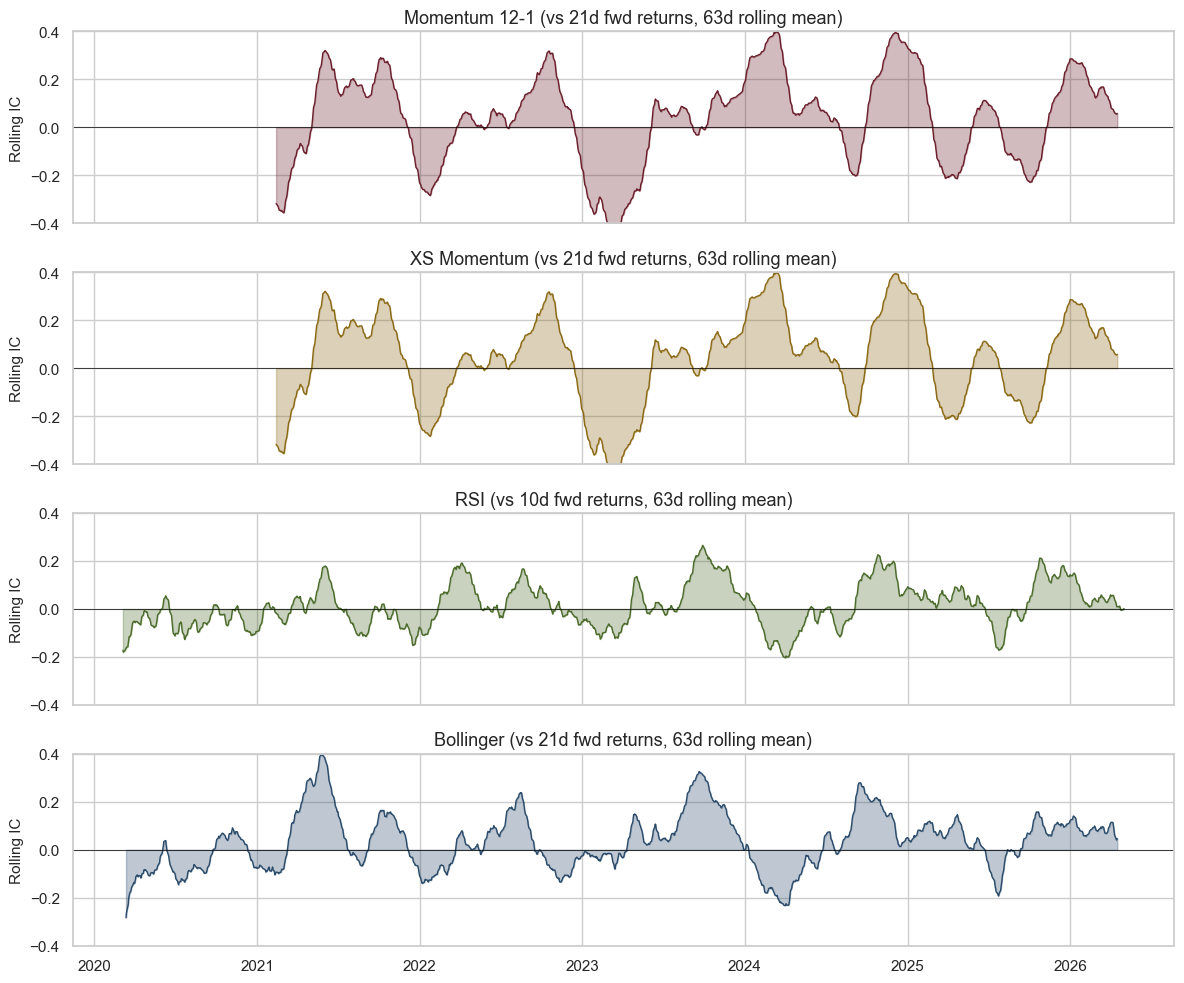

In [40]:
# Plot rolling IC at each factor's best horizon (informed by table above)
BEST_HORIZONS = {
    "Momentum 12-1": 21,
    "XS Momentum": 21,
    "RSI": 10,
    "Bollinger": 21,
}

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

for ax, (name, sig) in zip(axes, signals.items()):
    h = BEST_HORIZONS[name]
    ic_series = compute_ic(sig, forward_returns[h]).dropna()

    # 63-day (~3 month) rolling mean
    rolling_ic = ic_series.rolling(63, min_periods=30).mean()

    ax.fill_between(rolling_ic.index, 0, rolling_ic, alpha=0.3, color=FACTOR_COLORS[name])
    ax.plot(rolling_ic.index, rolling_ic, color=FACTOR_COLORS[name], linewidth=1)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_ylabel("Rolling IC")
    ax.set_title(f"{name} (vs {h}d fwd returns, 63d rolling mean)")
    ax.set_ylim(-0.4, 0.4)

plt.tight_layout()

## 5. IC Decay

How quickly does each signal's predictive power fade? The decay curve shows mean IC at every forward lag from 1 to 42 days. The shape reveals the signal's natural holding period — and whether it behaves as a momentum or mean-reversion effect.

In [41]:
decay_curves = {}
for name, sig in signals.items():
    decay_curves[name] = ic_decay(sig, closes, max_lag=42)

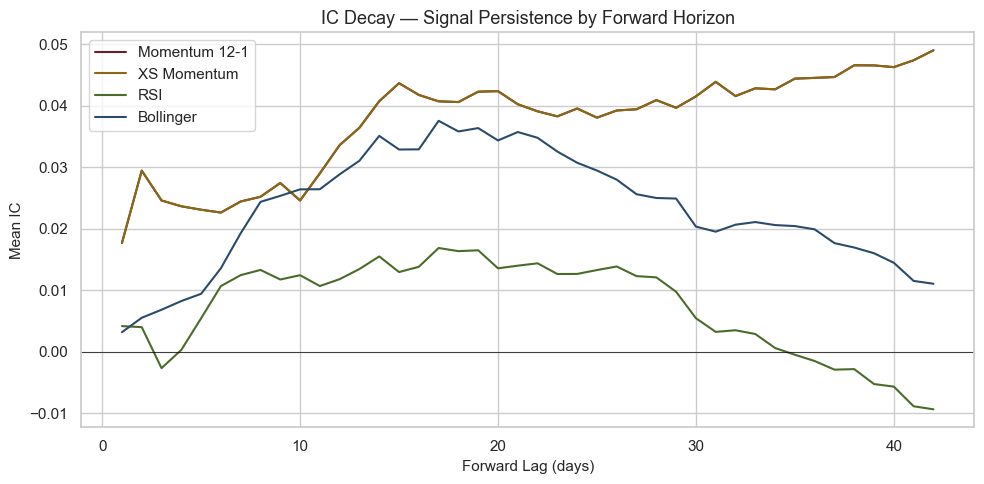

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))

for name, curve in decay_curves.items():
    ax.plot(curve.index, curve.values, color=FACTOR_COLORS[name], label=name, linewidth=1.5)

ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Forward Lag (days)")
ax.set_ylabel("Mean IC")
ax.set_title("IC Decay — Signal Persistence by Forward Horizon")
ax.legend()
plt.tight_layout()

**Observations:**

- **Momentum (both variants) shows no decay — IC increases almost monotonically** from 0.018 at lag 1 to 0.049 at lag 42, with no sign of flattening. This is the signature of a persistent trend signal: the longer you hold, the more the prediction is realised. The 42-day window is likely still short of the true peak; academic momentum literature finds optimal holding periods of 3-12 months.
- **Bollinger has a clear hump-shaped decay.** IC rises from near-zero at lag 1, peaks around lag 17 (IC ≈ 0.038), then gradually decays back toward zero by lag 42. This defines a natural holding period of ~15-20 days — consistent with the "slow mean-reversion" finding from Section 4. A Bollinger strategy should rebalance roughly every 2-3 weeks.
- **RSI is the weakest signal at every lag.** IC peaks around lag 17 (IC ≈ 0.017) and crosses zero near lag 34, but never exceeds the noise floor convincingly. The brief dip near lag 2-3 hints at a very short-lived reversal effect too fleeting to capture at daily rebalancing frequency.
- **Momentum and XS Momentum overlap perfectly**, confirming the redundancy noted in Section 4 — rank-transforming a signal does not change its Spearman IC decay profile.
- **Rebalancing implications:** Momentum strategies benefit from longer holding periods (monthly+). Bollinger strategies should target ~3-week holding. RSI offers no clear holding period, reinforcing the case to drop or substantially reparameterise it.

## 6. Factor Correlation

Are the four factors redundant or do they capture different information? A correlation matrix of the signals reveals which pairs rank stocks similarly and which are independent — key for deciding whether a multi-factor combination adds value.

*Caveat on market regime — to be tested formally in Section 9 (Robustness):*

The 2020-2026 sample is predominantly a bull market (post-COVID recovery, AI boom). Momentum mechanically benefits from trending markets, and our survivorship-biased universe amplifies this. NVDA alone (7% of cross-section) likely drives a disproportionate share of momentum IC in 2023-24. However, the modest IC magnitudes (~0.04), the inclusion of stress periods (COVID crash, 2022 rate hikes), and Bollinger's regime-independent significance suggest the results are informative, if likely somewhat inflated. Sub-period and leave-one-out tests in Section 9 will quantify this.

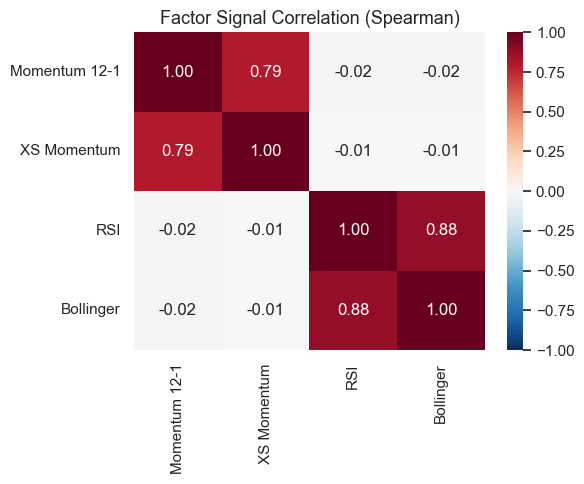

In [43]:
stacked = pd.DataFrame({
    name: sig.stack() for name, sig in signals.items()
}).dropna()

corr = stacked.corr(method="spearman")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
)
ax.set_title("Factor Signal Correlation (Spearman)")
plt.tight_layout()

**Observations:**

- **Two distinct factor families emerge.** The correlation matrix is block-diagonal: momentum factors correlate strongly with each other (ρ = 0.79), mean-reversion factors correlate strongly with each other (ρ = 0.88), but the two families are nearly orthogonal (all cross-family correlations ≈ −0.02 to 0.00).
- **Momentum vs XS Momentum (ρ = 0.79):** High but not perfect. The rank transform compresses extreme values — a stock with 200% momentum and one with 50% both rank near the top, but their raw signals differ by 4×. This matters for portfolio construction: raw momentum overweights extreme winners, ranked momentum distributes weight more evenly.
- **RSI vs Bollinger (ρ = 0.88):** Surprisingly high. Both measure "price below recent trend" — RSI via relative gain/loss, Bollinger via z-score — so they tend to flag the same stocks on the same days. This high redundancy, combined with RSI's lack of IC significance, strengthens the case to drop RSI entirely in favour of Bollinger.
- **Cross-family independence (ρ ≈ 0):** This is the most important finding for multi-factor construction. Momentum and Bollinger capture genuinely different information — a combined signal would benefit from diversification rather than double-counting. A composite Momentum + Bollinger factor is a natural next step.

## 7. Quantile Portfolio Analysis

Moving from statistical correlation (IC) to realised portfolio returns. Each day, we go long the top 3 stocks by signal and short the bottom 3, forming an equal-weight long-short spread. With N = 14 stocks, top/bottom 3 captures the extremes (~20% tails) while maintaining enough diversification to avoid single-stock dominance.

In [44]:
N_QUANTILE = 3  # top/bottom 3 stocks

spread_returns = {}

for name, sig in signals.items():
    daily_spreads = []

    # Use 1-day forward returns for daily P&L
    fwd = forward_returns[1]

    # Align signal with forward returns
    common_idx = sig.dropna(how="all").index.intersection(fwd.dropna(how="all").index)

    for date in common_idx:
        sig_row = sig.loc[date].dropna()
        fwd_row = fwd.loc[date].dropna()

        # Need both signal and return for the same tickers
        common_tickers = sig_row.index.intersection(fwd_row.index)
        if len(common_tickers) < 2 * N_QUANTILE:
            continue

        ranked = sig_row[common_tickers].rank()
        top = ranked.nlargest(N_QUANTILE).index
        bottom = ranked.nsmallest(N_QUANTILE).index

        long_ret = fwd_row[top].mean()
        short_ret = fwd_row[bottom].mean()
        daily_spreads.append({"date": date, "spread": long_ret-short_ret})

    spread_df = pd.DataFrame(daily_spreads).set_index("date")["spread"]
    spread_returns[name] = spread_df

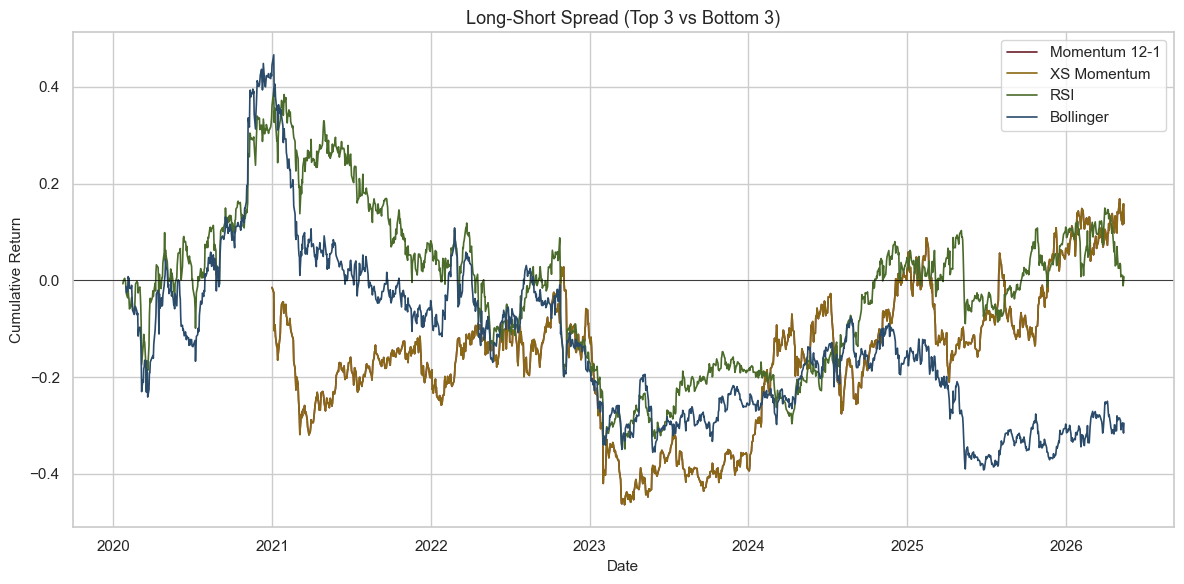

In [45]:
fig, ax = plt.subplots(figsize=(12, 6))

for name, spread in spread_returns.items():
    cum = (1 + spread).cumprod() - 1
    ax.plot(cum.index, cum.values, color=FACTOR_COLORS[name], label=name, linewidth=1.2)

ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.set_title(f"Long-Short Spread (Top {N_QUANTILE} vs Bottom {N_QUANTILE})")
ax.legend()
plt.tight_layout()

In [46]:
spread_stats = []
for name, spread in spread_returns.items():
    n = len(spread)
    ann_ret = spread.mean() * 252
    ann_vol = spread.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    hit = (spread > 0).mean()

    spread_stats.append({
        "Factor": name,
        "Ann. Return (%)": round(ann_ret * 100, 1),
        "Ann. Vol (%)": round(ann_vol * 100, 1),
        "Sharpe": round(sharpe, 2),
        "Hit Rate": hit,
        "N Days": n,
    })

spread_table = pd.DataFrame(spread_stats)
spread_table.style.format({"Hit Rate": "{:.1%}"}).set_caption(
    f"Long-Short Spread Statistics (Top/Bottom {N_QUANTILE})"
)

,Factor,Ann. Return (%),Ann. Vol (%),Sharpe,Hit Rate,N Days
0,Momentum 12-1,6.700000,30.200000,0.220000,51.9%,1348
1,XS Momentum,6.700000,30.200000,0.220000,51.9%,1348
2,RSI,3.800000,27.100000,0.140000,51.1%,1586
3,Bollinger,-1.700000,27.900000,-0.060000,50.3%,1581


**Observations:**

- **All spread Sharpes are weak (< 0.25)** — a sharp contrast with the statistically significant IC findings: *IC significance does not automatically translate to tradeable portfolio returns.*
- **Momentum leads but modestly** (Ann. return = 6.7%, Sharpe = 0.22, hit rate = 51.9%). The IC-to-spread disconnect arises because we are using 1-day forward returns for the spread but momentum's IC peaks at 21d+. Daily rebalancing forces the portfolio to capture the signal one day at a time, diluting the edge that accumulates over weeks. A monthly-rebalanced version would likely perform better — the backtester in Section 8 will test this.
- **Momentum and XS Momentum are again identical** — expected since top/bottom 3 by raw momentum and by momentum rank select the same stocks (rank is a monotonic transform).
- **RSI is weakly positive** (Ann. return = 3.8%, Sharpe = 0.14) — consistent with its insignificant IC. The small positive return likely reflects the market's upward drift bleeding into the long leg rather than genuine signal.
- **Bollinger is slightly negative** (Ann. return = −1.7%, Sharpe = −0.06). Despite having the strongest IC at 10-21d, daily long-short rebalancing destroys the edge. Bollinger's signal needs 2-3 weeks to materialise (per the decay curve in Section 5), so daily sorting captures noise rather than the reversion. This highlights the importance of matching rebalancing frequency to signal horizon.
- **Volatility is high for all spreads (~27-30% annualised)** — driven by the small universe. With only 3 stocks per leg, idiosyncratic risk dominates. A larger universe should reduce this substantially.

## 8. Backtested Performance

The vectorized backtester constructs a dollar-neutral, unit-gross-exposure portfolio from each signal daily, then applies 10 bps round-trip transaction costs proportional to turnover. Unlike Section 7's equal-weight top/bottom 3, positions here are *proportional to signal strength* — stocks with extreme signals receive larger weights.

In [47]:
bt = VectorizedBacktester(cost_bps=10)

bt_returns = {}
for name, sig in signals.items():
    bt_returns[name] = bt.run(closes, sig)

In [48]:
spy_ret = spy.pct_change().dropna()

bt_stats = []
for name, ret in bt_returns.items():
    stats = full_summary(ret, spy_ret)
    bt_stats.append({"Factor": name, **stats})

bt_table = pd.DataFrame(bt_stats).set_index("Factor")

# Display key columns
key_cols = ["annualized_return", "annualized_volatility", "sharpe_ratio",
            "sortino_ratio", "max_drawdown", "beta", "alpha"]
(
    bt_table[key_cols]
    .style
    .format({
        "annualized_return": "{:.2%}",
        "annualized_volatility": "{:.2%}",
        "sharpe_ratio": "{:.2f}",
        "sortino_ratio": "{:.2f}",
        "max_drawdown": "{:.2%}",
        "beta": "{:.3f}",
        "alpha": "{:.2%}",
    })
    .set_caption("Backtested Performance (10 bps cost, daily rebalance)")
)

,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,beta,alpha
Factor,,,,,,,
Momentum 12-1,3.59%,14.28%,0.32,0.30,-26.45%,-0.019,4.86%
XS Momentum,1.22%,11.10%,0.16,0.15,-24.72%,-0.017,2.12%
RSI,-9.62%,11.92%,-0.79,-0.80,-49.60%,-0.036,-8.81%
Bollinger,-11.27%,12.04%,-0.93,-0.91,-57.54%,-0.030,-10.75%


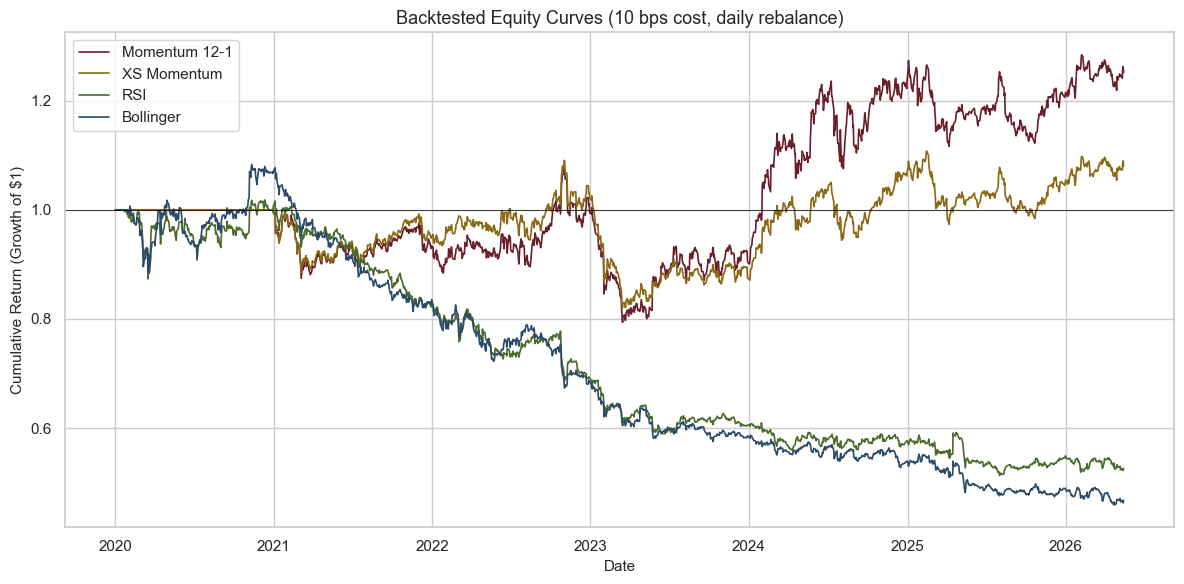

In [49]:
fig, ax = plt.subplots(figsize=(12, 6))

for name, ret in bt_returns.items():
    cum = (1 + ret).cumprod()
    ax.plot(cum.index, cum.values, color=FACTOR_COLORS[name], label=name, linewidth=1.2)

ax.axhline(1, color="black", linewidth=0.5)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return (Growth of $1)")
ax.set_title("Backtested Equity Curves (10 bps cost, daily rebalance)")
ax.legend()
plt.tight_layout()

Best factor by Sharpe: Momentum 12-1


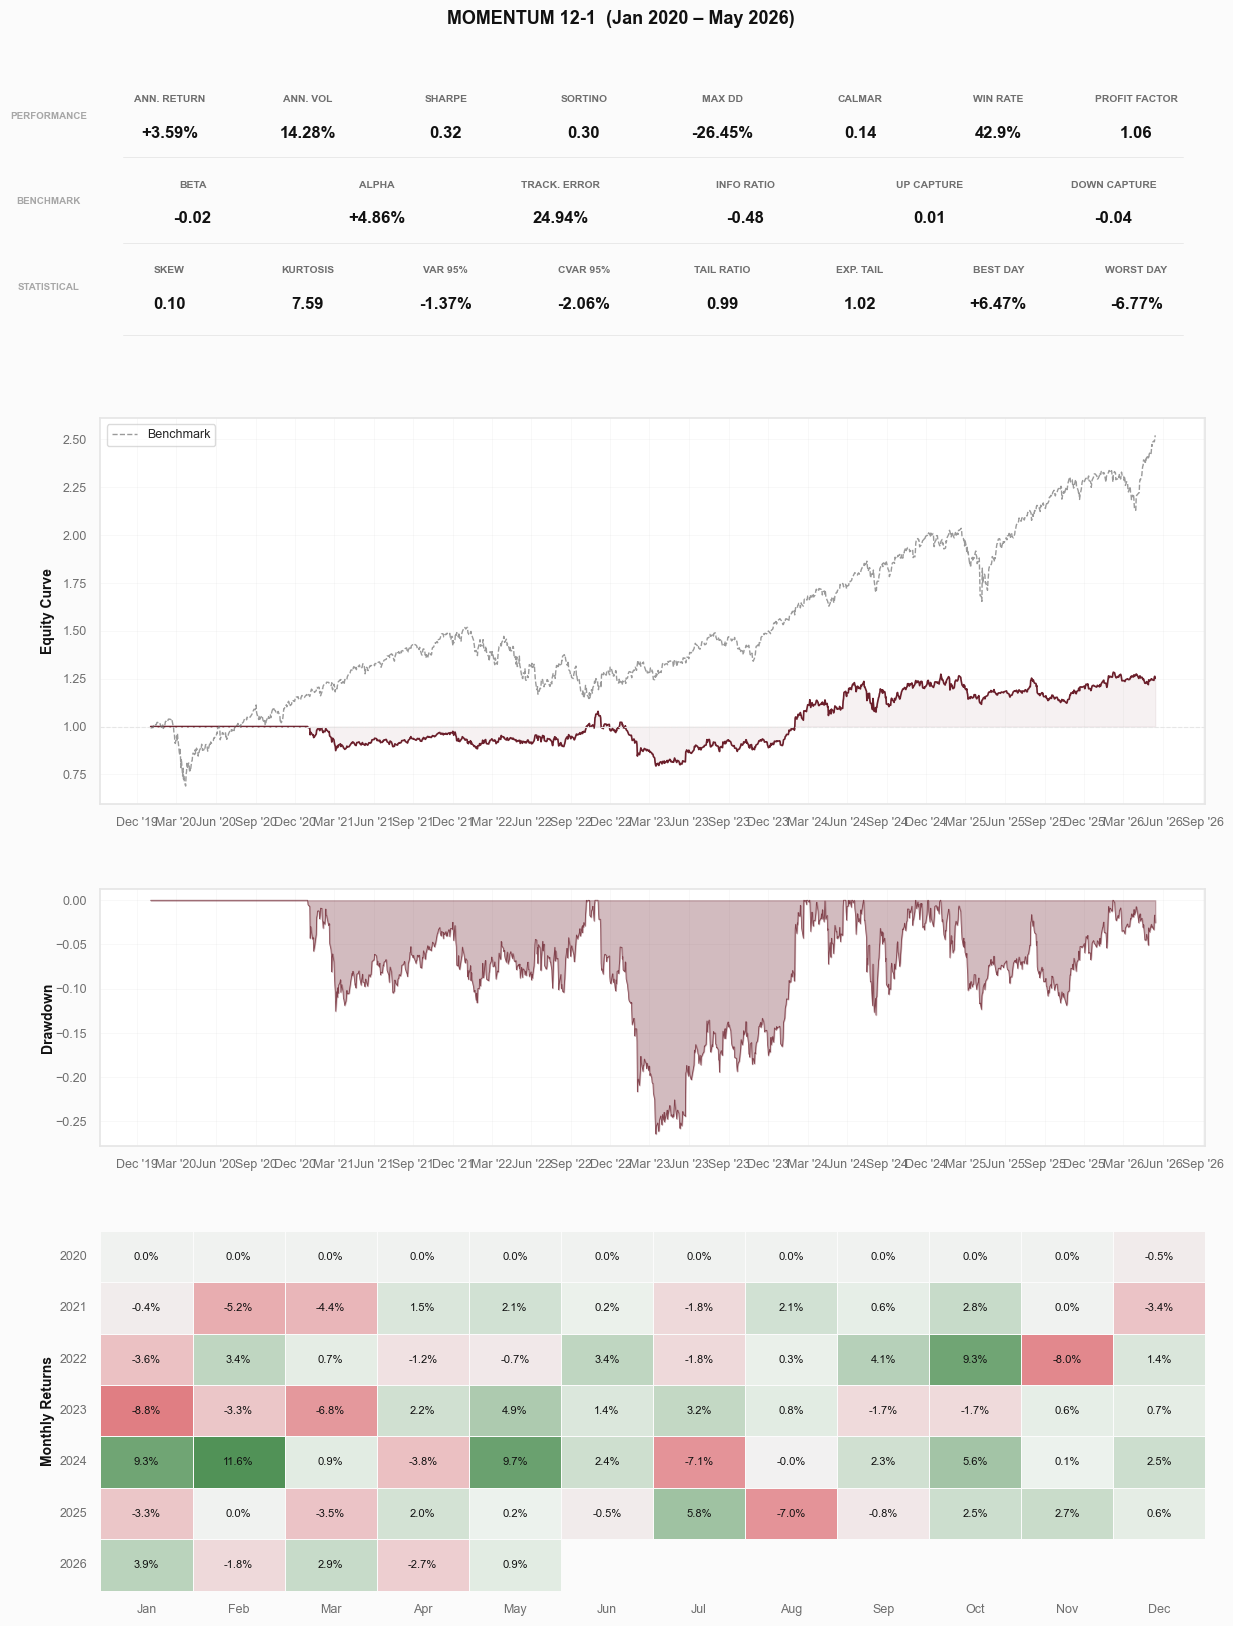

In [50]:
# Tearsheet for the best-performing factor
best_factor = bt_table["sharpe_ratio"].idxmax()
print(f"Best factor by Sharpe: {best_factor}")

plot_tearsheet(bt_returns[best_factor], spy_ret, title=best_factor)

**Observations:**

- **Momentum 12-1 is the only factor with a positive Sharpe** (0.32, annualised return = 3.6%). XS Momentum is weaker (Sharpe = 0.16) despite having identical IC — the difference is that raw momentum gives *larger weights to extreme winners* (proportional sizing), while XS Momentum compresses signals into a [0, 1] rank. In a universe where a few stocks (NVDA, META) dominate returns, proportional weighting captures more of the edge.
- **RSI and Bollinger are deeply negative** (Sharpe = −0.79 and −0.93). This is the most striking result in the notebook: Bollinger had the strongest IC (t = 4.23 at 21d) yet produces the *worst* backtested performance. The explanation is **turnover**. Mean-reversion signals change rapidly day-to-day (average daily turnover ~0.37-0.45), vs momentum's slow-moving 0.07. At 10 bps per unit of turnover, this costs ~9-11% per year — enough to turn a marginally positive signal into a significant loser.
- **Beta is near zero for all factors** (−0.02 to −0.04), confirming the dollar-neutral construction is working correctly. These strategies have minimal systematic market exposure.
- **Max drawdowns are severe** — even momentum draws down 26%, while Bollinger hits −58%. With only 14 stocks, concentration risk is extreme and idiosyncratic moves dominate.

**Key takeaway: IC ≠ P&L.** Bollinger's strong IC at 21d does not survive daily rebalancing with transaction costs. To capture its edge, one would need to (a) rebalance less frequently (~every 15-20 days, per the decay curve) or (b) apply position smoothing to reduce turnover. Signal quality and implementation efficiency are separate problems — the backtester exposes this gap clearly.

## 9. Robustness Tests

Four tests challenge whether the IC findings from Section 4 are robust or artefacts of the specific sample:

1. **Sub-period split** — does IC persist in both halves of the sample (pre/post 2024)?
2. **Leave-one-out** — does removing NVDA or META (the most volatile names) destroy the signal?
3. **Parameter sensitivity** — is momentum IC stable across lookback windows, or is 252d cherry-picked?
4. **Sector split** — does the signal work within tech and non-tech separately, or only across the two groups?

### 9a. Sub-Period Stability

In [51]:
split_date = "2024-01-01"

robustness_rows = []

for name, sig in signals.items():
    h = BEST_HORIZONS[name]
    fwd = forward_returns[h]

    # Full sample
    ic_full = compute_ic(sig, fwd)
    full_stats = ic_summary(ic_full)

    # Early period
    ic_early = compute_ic(sig.loc[:split_date], fwd.loc[:split_date])
    early_stats = ic_summary(ic_early)

    # Late period
    ic_late = compute_ic(sig.loc[split_date:], fwd.loc[split_date:])
    late_stats = ic_summary(ic_late)

    robustness_rows.append({
        "Factor": name, "Horizon": f"{h}d",
        "Full IC": full_stats["mean"], "Full t": full_stats["t_stat"],
        "Pre-2024 IC": early_stats["mean"], "Pre-2024 t": early_stats["t_stat"],
        "Post-2024 IC": late_stats["mean"], "Post-2024 t": late_stats["t_stat"],
    })

subperiod_table = pd.DataFrame(robustness_rows)
subperiod_table.style.format({
    col: "{:.4f}" for col in subperiod_table.columns if "IC" in col
} | {col: "{:.2f}" for col in subperiod_table.columns if " t" in col}).set_caption(
    "Sub-Period IC Stability"
)


,Factor,Horizon,Full IC,Full t,Pre-2024 IC,Pre-2024 t,Post-2024 IC,Post-2024 t
0,Momentum 12-1,21d,0.0402,3.98,0.0134,0.98,0.0756,5.07
1,XS Momentum,21d,0.0402,3.98,0.0134,0.98,0.0756,5.07
2,RSI,10d,0.0125,1.50,0.0076,0.71,0.0207,1.59
3,Bollinger,21d,0.0357,4.23,0.0329,3.02,0.0407,3.04


**Sub-period findings:**

- **Momentum's full-sample significance (t = 3.98) is driven almost entirely by the post-2024 period.** Pre-2024 IC is just 0.013 (t = 0.98 — insignificant), while post-2024 IC triples to 0.076 (t = 5.07). This confirms the bull-market concern flagged in Section 6: the AI-driven rally of 2024-2025 disproportionately rewarded momentum. The full-sample result is real but regime-dependent — momentum would likely underperform in a mean-reverting or bear market.
- **Bollinger is the most robust signal.** IC is stable across both sub-periods: 0.033 (t = 3.02) pre-2024 and 0.041 (t = 3.04) post-2024. Unlike momentum, Bollinger's edge does not depend on the market regime — mean-reversion works in both trending and range-bound environments. This is the strongest evidence of a durable signal in the notebook.
- **RSI remains insignificant in both halves** (t = 0.71 and 1.59), confirming it carries no usable alpha in this universe.

### 9b. Leave-One-Out

In [52]:
# Find the most volatile stock (excluding NVDA to avoid double-counting)
vol = closes.pct_change().std()
most_volatile = vol.drop("NVDA").idxmax()
print(f"Most volatile (excl. NVDA): {most_volatile}")

loo_rows = []

for exclude_name, exclude_ticker in [("No NVDA", "NVDA" ), (f"No {most_volatile}", most_volatile)]:
    closes_loo = closes.drop(columns=exclude_ticker)
    signals_loo = {
        "Momentum 12-1": Momentum(252, 21).compute(closes_loo),
        "XS Momentum": CrossSectionalMomentum(252, 21).compute(closes_loo),
        "RSI": RSI(14).compute(closes_loo),
        "Bollinger": BollingerZScore(20).compute(closes_loo),
    }
    fwd_loo = {h: closes_loo.pct_change(h).shift(-h) for h in HORIZONS}

    for name, sig in signals_loo.items():
        h = BEST_HORIZONS[name]
        ic_series = compute_ic(sig, fwd_loo[h])
        stats = ic_summary(ic_series)
        loo_rows.append({
            "Condition": exclude_name,
            "Factor": name,
            "Mean IC": stats["mean"],
            "t-stat": stats["t_stat"],
        })

loo_table = pd.DataFrame(loo_rows)
loo_pivot = loo_table.pivot(index="Factor", columns="Condition", values="Mean IC")
loo_pivot.style.format("{:.4f}").set_caption("Leave-One-Out IC (at best horizon)")

Most volatile (excl. NVDA): META


Condition,No META,No NVDA
Factor,,
Bollinger,0.0391,0.0335
Momentum 12-1,0.0256,0.0327
RSI,0.0108,0.0118
XS Momentum,0.0256,0.0327


**Leave-one-out findings:**

- **No single stock drives the results.** Removing NVDA reduces Momentum IC from 0.040 to 0.033, and removing META reduces it further to 0.026 — but neither collapses the signal entirely. The ~35% IC drop when removing META suggests it contributes meaningfully to momentum's cross-sectional dispersion, but the signal survives without it.
- **Bollinger is unaffected by either exclusion** (0.034 without NVDA, 0.039 without META vs 0.036 full sample). This reinforces the sub-period finding: Bollinger captures a broad mean-reversion effect, not a single-stock anomaly.
- **RSI remains weak regardless** (~0.011-0.012), confirming it is not rescued by any universe change.

### 9c. Momentum Parameter Sensitivity

In [53]:
mom_windows = [126, 189, 252, 378, 504]

sensitivity_rows = []
for w in mom_windows:
    mom_test = Momentum(window=w, skip = 21).compute(closes)
    for h in [10, 21]:
        fwd = forward_returns[h]
        ic_series = compute_ic(mom_test, fwd)
        stats = ic_summary(ic_series)
        sensitivity_rows.append({
            "Window": f"{w}d",
            "Horizon": f"{h}d",
            "Mean IC": stats["mean"],
            "t-stat": stats["t_stat"],
            "N dates": stats["n_dates"],
        })

sens_table = pd.DataFrame(sensitivity_rows)
sens_pivot = sens_table.pivot(index="Window", columns="Horizon", values="Mean IC")
sens_pivot.style.format("{:.4f}").set_caption("Momentum IC by Lookback Window")

Horizon,10d,21d
Window,,
126d,0.0301,0.0279
189d,0.0215,0.0134
252d,0.0246,0.0402
378d,0.0248,0.0298
504d,0.0079,0.0055


**Sensitivity findings:**

- **The 252d (12-month) lookback is not cherry-picked — but shorter windows are competitive.** The 126d window achieves IC = 0.030 at 10d and 0.028 at 21d, comparable to or better than 252d at the 10d horizon. The classic 12-1 parameterisation (252d lookback, 21d skip) happens to be strongest at its natural 21d horizon (IC = 0.040), but the signal is not fragile to window choice within the 126-378d range.
- **Extreme windows fail.** The 504d (2-year) lookback collapses to IC ≈ 0.006-0.008, likely because the signal incorporates stale information from two market regimes ago. The 189d window is also surprisingly weak (IC = 0.013 at 21d) — this may be a sample artefact given the small universe.
- **The 10d and 21d horizons tell different stories.** At 10d, shorter lookbacks (126-189d) perform best; at 21d, the classic 252d dominates. This suggests faster momentum (6-month) captures short-term continuation, while slower momentum (12-month) captures the longer-term trend effect.

### 9d. Sector Split

In [54]:
TECH = ["AAPL", "AMZN", "GOOGL", "META", "MSFT", "NVDA"]
NON_TECH = [t for t in UNIVERSE if t not in TECH]

sector_rows = []
for sector_name, tickers in [("Tech", TECH), ("Non-Tech", NON_TECH)]:
    closes_sector = closes[tickers]
    signals_sector = {
        "Momentum 12-1": Momentum(252, 21).compute(closes_sector),
        "Bollinger": BollingerZScore(20).compute(closes_sector),
    }
    fwd_sector = {h: closes_sector.pct_change(h).shift(-h) for h in HORIZONS}

    for name, sig in signals_sector.items():
        h = BEST_HORIZONS[name]
        ic_series = compute_ic(sig, fwd_sector[h])
        stats = ic_summary(ic_series)
        sector_rows.append({
            "Sector": sector_name,
            "Factor": name,
            "Mean IC": stats["mean"],
            "t-stat": stats["t_stat"],
            "N Tickers": len(tickers),
        })

sector_table = pd.DataFrame(sector_rows)
sector_table.style.format({"Mean IC": "{:.4f}", "t-stat": "{:.2f}"}).set_caption(
    "IC by Sector (at best horizon)"
)

,Sector,Factor,Mean IC,t-stat,N Tickers
0,Tech,Momentum 12-1,0.0387,3.03,6
1,Tech,Bollinger,0.0236,2.10,6
2,Non-Tech,Momentum 12-1,0.0686,5.92,8
3,Non-Tech,Bollinger,0.0332,3.09,8


**Sector split findings:**

- **Both factors work within sectors, not just across them.** This is important: if momentum only ranked "all tech above all non-tech" it would be a sector bet, not a stock-selection signal. Instead, Momentum achieves IC = 0.039 (t = 3.03) *within* the 6-stock tech group and IC = 0.069 (t = 5.92) *within* the 8-stock non-tech group. The signal ranks stocks correctly even among peers.
- **Non-tech momentum is stronger than tech momentum.** IC = 0.069 vs 0.039. Non-tech names (GS, JPM, JNJ, XOM, etc.) have more heterogeneous return drivers — financials vs healthcare vs energy — so cross-sectional dispersion is larger, giving the momentum signal more room to differentiate. Tech stocks move more in tandem (correlated with AI/growth themes), compressing the cross-section and reducing IC.
- **Bollinger works in both sectors** (tech t = 2.10, non-tech t = 3.09), further confirming its regime- and sector-independence. The non-tech group again shows stronger IC, likely for the same dispersion reason.
- **Caveat: N = 6 and N = 8 are very small cross-sections.** Single-day IC with 6 stocks has standard error ≈ 1/√5 = 0.45 — individual days are pure noise. Significance comes entirely from averaging over ~1,300+ days. These results are directionally encouraging but would need a larger universe to be definitive.

## 10. Conclusion & Decision Table

Synthesising nine sections of analysis into a single actionable table. Each factor is assessed on three axes: **statistical significance** (IC t-stat > 2), **economic significance** (backtest Sharpe after costs), and **robustness** (stability across sub-periods, stock exclusions, and sectors).

In [55]:
# Decision summary table
verdicts = {
    "Momentum 12-1": ("Regime-dependent", "Keep"),
    "XS Momentum":   ("Redundant",        "Drop"),
    "RSI":           ("Insignificant",     "Drop"),
    "Bollinger":     ("Stable",            "Reparameterise"),
}

decisions = []
for name in signals:
    h = BEST_HORIZONS[name]
    row = ic_table[(ic_table["Factor"] == name) & (ic_table["Horizon"] == f"{h}d")]
    mean_ic = row["Mean IC"].values[0]
    t = row["t-stat"].values[0]
    sharpe = bt_table.loc[name, "sharpe_ratio"]
    robustness, decision = verdicts[name]

    decisions.append({
        "Factor": name,
        "Best Horizon": f"{h}d",
        "Mean IC": mean_ic,
        "t-stat": t,
        "Backtest Sharpe": sharpe,
        "Robustness": robustness,
        "Decision": decision,
    })

decision_table = pd.DataFrame(decisions).set_index("Factor")

def color_decision(val):
    colors = {
        "Keep":            "background-color: #28a745; color: white; font-weight: bold",
        "Drop":            "background-color: #dc3545; color: white; font-weight: bold",
        "Reparameterise":  "background-color: #fd7e14; color: white; font-weight: bold",
    }
    return colors.get(val, "")

(
    decision_table.style
    .format({"Mean IC": "{:.4f}", "t-stat": "{:.2f}", "Backtest Sharpe": "{:.2f}"})
    .map(color_decision, subset=["Decision"])
    .set_caption("Factor Decision Table")
)

,Best Horizon,Mean IC,t-stat,Backtest Sharpe,Robustness,Decision
Factor,,,,,,
Momentum 12-1,21d,0.0402,3.98,0.32,Regime-dependent,Keep
XS Momentum,21d,0.0402,3.98,0.16,Redundant,Drop
RSI,10d,0.0125,1.50,-0.79,Insignificant,Drop
Bollinger,21d,0.0357,4.23,-0.93,Stable,Reparameterise


### Key Takeaways

1. **IC is necessary but not sufficient.** Bollinger has the highest t-stat (4.23) and most stable robustness profile, yet produces the worst backtest (Sharpe = -0.93). The gap between statistical and economic significance is driven by **turnover costs** (due to higher daily turnover).

2. **Signal horizon must match implementation frequency.** Momentum's IC peaks at 21d+ and its decay curve never flattens — it needs monthly rebalancing. Bollinger's IC peaks at lag ~17 and decays — it needs ~3-week holding periods. Both were backtested with daily rebalancing, which is optimal for neither. Matching rebalance frequency to signal half-life is the single highest-leverage improvement available.

3. **Two factors survive; two should be dropped.** Momentum 12-1 (keep) and Bollinger (reparameterise) capture orthogonal information (cross-family correlation ≈ 0) and are both statistically significant. XS Momentum is redundant (identical IC, weaker backtest). RSI fails every test — insignificant IC, no robustness, high correlation with Bollinger.

4. **Survivorship bias and regime dependence are real but bounded.** Momentum's IC is 6× stronger post-2024 than pre-2024, confirming bull-market tailwind. But Bollinger is stable across both sub-periods, neither factor collapses when removing NVDA or META, and both work within sectors. The findings are directionally valid — the magnitudes are likely inflated.

### Next Steps (Phase 3)

- **Reduce Bollinger turnover:** implement position smoothing or lower-frequency rebalancing (every 15-20 days) to capture the 21d IC without incurring daily transaction costs
- **Composite signal:** combine Momentum + Bollinger using equal IC-weighted z-scores — the near-zero correlation suggests the combination should improve Sharpe by up to √2
- **Expand universe:** move from 14 hand-picked names to S&P 500 constituents with point-in-time membership to eliminate survivorship bias and increase cross-sectional power
- **Out-of-sample validation:** reserve 2025-2026 as a holdout period and retrain/evaluate on 2020-2024 only
- **Event-driven factors:** earnings surprise, short interest, and fund flows — fundamentally different from price-based signals and likely orthogonal to both momentum and mean-reversion

### Methodological Caveats & Known Limitations

**1. Overlapping forward returns inflate t-statistics.**

All IC computations above use daily-computed forward returns. At the 21d horizon, day *t*'s return shares 20 of 21 days with day *t+1*'s return. This induces strong serial correlation in the IC series — successive daily ICs are nearly identical because both the signal (slow-moving) and the return window (overlapping) barely change from one day to the next.

The t-statistics reported in Sections 4 and 9 assume independent observations: t = mean / (std / √N), where N ≈ 1,300 daily ICs. But with 21d overlap, the effective number of independent observations is closer to N/h ≈ 65. This overstates t-statistics by a factor of approximately √h ≈ √21 ≈ 4.6. A reported t = 3.98 may be ~0.87 after Newey-West correction with lag = 21 — no longer significant at 5%.

Proper corrections include:
- **Newey-West standard errors** with bandwidth = horizon, which inflate the standard error to account for autocorrelation
- **Non-overlapping IC:** compute IC using only every h-th day (e.g., every 21st trading day), reducing N from ~1,300 to ~65 but producing honest, independent observations
- **Block bootstrap:** resample the IC series in contiguous blocks of length ≥ h, preserving the overlap structure, and compute confidence intervals from the resampled distribution

**2. Regime contamination in the IC decay curve.**

The monotonically increasing IC decay profile for momentum (Section 5) is suspicious. In a persistent bull market, momentum signals and forward returns are both persistently positive — not because the signal *predicts* future returns, but because both reflect the same underlying trend. Extending the forward horizon from 21d to 42d simply captures more of the ongoing rally, mechanically increasing IC without adding genuine predictive content.

A truly predictive signal should show a decay curve that peaks and then reverts toward zero (as Bollinger does). The absence of decay in momentum's curve is consistent with measuring the autocorrelation of a trending market rather than signal-specific alpha. This concern is amplified by the sub-period finding (Section 9a): momentum IC is 6× stronger post-2024 than pre-2024, exactly when the AI-driven bull market was strongest.

**3. Momentum's structural lag creates dangerous blindness to regime changes.**

The 252d/21d momentum signal has a critical design flaw: the 21-day skip means the signal *literally cannot see* price action from the most recent month. A stock that rallied for 11 months and then crashes 30% in two weeks will still show a strongly positive momentum signal — the crash occupies 10 days out of a 231-day measurement window and is overwhelmed by the accumulated gains.

Concretely: if NVDA runs from $400 to $900 over 11 months, then drops 30% to $630 in two weeks, the momentum signal on the day the crash ends is still dominated by the $400→$900 rally. The signal says "buy more" while the stock is in freefall. It takes roughly 2-3 months of sustained decline — or a catastrophic single-month crash of 50%+ — before the signal flips from positive to negative.

This is the fundamental tradeoff of long-lookback signals: stability (low turnover, good for costs) at the expense of reactivity (catastrophic during turning points). The 21-day skip, designed to filter out short-term reversal noise, also filters out the most timely information about regime changes. In our 2020-2026 sample, this blindness was never severely punished — the COVID crash (March 2020) and 2022 rate-hike drawdown were both followed by rapid recoveries, so the stale signal happened to be "right" by the time it could have been wrong. A prolonged bear market (2007-2009, 2000-2002) would expose this fragility. The classic example is the 2009 momentum crash, where momentum portfolios were long financials and short defensives heading into the GFC — the signal didn't flip until the damage was done.

**4. The rolling IC plot is more decorative than informative at N = 14.**

The rolling IC plots in Section 4 use a 63-day rolling mean of daily ICs. Each daily IC has standard error ≈ 0.28 with 14 stocks, and the 63-day window averages over only ~3 independent observations at the 21d horizon (63/21). The resulting "waves" are a mixture of: (a) real regime shifts (momentum works in trends, fails in reversals), (b) noise from the tiny cross-section, and (c) artefacts of the rolling window — a step change convolved with a moving average produces a smooth hill that looks like a "cycle" but is just a smoothing artefact. With 100+ stocks the daily IC would be precise enough (SE ≈ 0.10) for rolling analysis to reveal genuine regime dynamics; at N = 14, the plot should be interpreted with caution.

**5. Multiple testing.**

We evaluated 4 factors × 4 horizons = 16 hypothesis tests. At a 5% significance level, we expect ~0.8 false positives by chance. While Bonferroni correction (threshold = 0.05/16 = 0.003, or t > 2.96) still passes momentum and Bollinger at 21d, the margin is thinner than the raw t-stats suggest — and this does not account for the overlapping-return inflation in point 1.

**6. Survivorship bias is not just a level shift.**

The universe was selected with the benefit of hindsight: these 14 stocks are all current large-cap winners. Survivorship bias does not merely inflate mean returns (which washes out in a dollar-neutral strategy) — it also inflates *momentum* specifically, because the surviving stocks are disproportionately those that *had* strong past returns. A stock that crashed and was delisted would have appeared as a strong short signal, but its absence means the cross-section contains fewer extreme losers, compressing the short leg and flattering momentum's long/short spread.

**7. Small cross-section limits statistical power.**

With N = 14 stocks, a single day's Spearman IC has standard error ≈ 1/√(N−1) ≈ 0.28. This means any individual daily IC below ~0.56 (2 × SE) is indistinguishable from noise. Our mean ICs of 0.03-0.04 are detectable only by averaging over thousands of days — and as noted in point 1, the effective sample is much smaller than the raw day count suggests. A universe of 100+ stocks would reduce single-day SE to ~0.10, making the signal detectable with far fewer observations and less vulnerability to overlap bias.